In [78]:
# ==============================================================================
# IMPORTS
# ==============================================================================

from openpiv import tools, pyprocess, validation, filters, scaling
import numpy as np
import tifffile as tif
import matplotlib.pyplot as plt
import napari
import pathlib
import scipy

In [ ]:
# CROP OFF CORNERS AND VISUALIZE IN NAPARI

first_dataset = tif.imread('/mnt/crunch/Clark/Fly_TFM/data/first/first_best.tif')
sitting_reference = first_dataset[350]
unstressed_reference = first_dataset[-1]

top_left_corner_sitting_reference = sitting_reference[0:830, 0:670]
bottom_left_corner_sitting_reference = sitting_reference[1630:2048, 0:450]
bottom_right_corner_sitting_reference = sitting_reference[1470:2048, 1410:2048]
top_right_corner_sitting_reference = sitting_reference[0:580, 1510:2048]

top_left_corner_unstressed_reference = unstressed_reference[0:833, 0:673]
bottom_left_corner_unstressed_reference = unstressed_reference[1633:2048, 0:449]
bottom_right_corner_unstressed_reference = unstressed_reference[1473:2048, 1409:2048]
top_right_corner_unstressed_reference = unstressed_reference[0:577, 1505:2048]

viewer = napari.Viewer()

# viewer.add_image(top_left_corner_sitting_reference, name='Top Left Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(bottom_left_corner_sitting_reference, name='Bottom Left Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(bottom_right_corner_sitting_reference, name='Bottom Right Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(top_right_corner_sitting_reference, name='Top Right Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(sitting_reference, name='Original Image', colormap='gray', contrast_limits=[0, 255])

# viewer.add_image(top_left_corner_unstressed_reference, name='Top Left Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(bottom_left_corner_unstressed_reference, name='Bottom Left Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(bottom_right_corner_unstressed_reference, name='Bottom Right Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(top_right_corner_unstressed_reference, name='Top Right Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(unstressed_reference, name='Original Image', colormap='gray', contrast_limits=[0, 255])

napari.run()

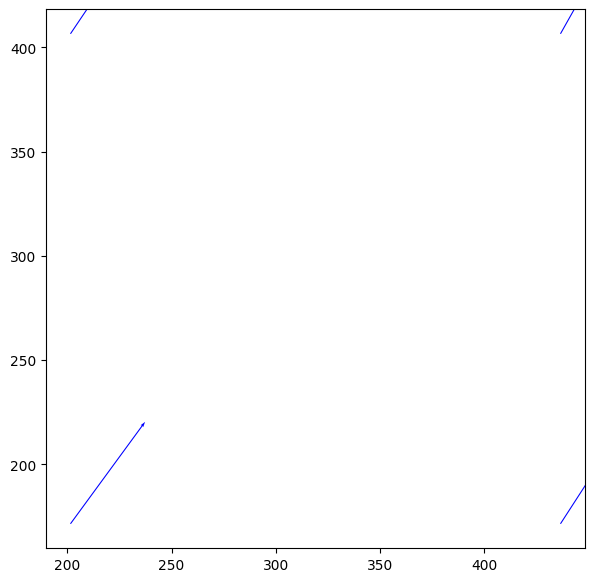

(<Figure size 700x700 with 1 Axes>, <Axes: >)

In [ ]:
# STEP 1: RUN COARSE FIRST PASS

# ------------------------------------------------------------------------------

# SECTION PIV parameters (window_size - overlap = step_size)

window_size = 225
search_size = 235
overlap = 0

# !SECTION

# ------------------------------------------------------------------------------

# SECTION Run the actual PIV

u_0, v_0, sig2noise = pyprocess.extended_search_area_piv(
    bottom_right_corner_sitting_reference.astype(np.int32),
    bottom_right_corner_unstressed_reference.astype(np.int32),
    window_size=window_size,
    overlap=overlap,
    dt=1,
    search_area_size=search_size,
    sig2noise_method='peak2peak'
)

# !SECTION

# ------------------------------------------------------------------------------

# SECTION Postprocessing

# Get mask of vectors, 0 = above threshold, 1 = below threshold
invalid_mask = validation.sig2noise_val(
    sig2noise,
    threshold=1.3
)

# Replace outliers with local mean
u_0_filtered, v_0_filtered = filters.replace_outliers(
    u_0,
    v_0,
    invalid_mask,
    method='localmean',
    max_iter=3,
    kernel_size=2
)

# Get x y coords of center of interrogation windows
x_0, y_0 = pyprocess.get_coordinates(
    image_size=bottom_right_corner_sitting_reference.shape,
    search_area_size=search_size,
    overlap=overlap
)

# Flip coords so that origin is bottom left corner
x, y, u_0_filtered, v_0_filtered = tools.transform_coordinates(
    x_0,
    y_0,
    u_0_filtered,
    v_0_filtered
)

# Save
tools.save('first_pass_results.txt', x_0, y_0, u_0_filtered, v_0_filtered, invalid_mask)

# !SECTION

# --- Visualize ---
fig, ax = plt.subplots(figsize=(7, 7))
tools.display_vector_field(
    pathlib.Path('first_pass_results.txt'),
    ax=ax,
    scaling_factor=1,
    scale=10,
    width=0.002,
)

In [ ]:
# STEP 2: WARP IMAGE BASED ON FIRST PASS RESULTS

# ------------------------------------------------------------------------------

